In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import LogLocator, NullFormatter
import struct

import scienceplots
from tqdm import tqdm

plt.style.use(['science','notebook'])
jax.config.update("jax_enable_x64", True)

from scipy.fft import fftn,ifftn,fftshift
from scipy.optimize import curve_fit
from numba import njit, prange, jit
from time import time
import sys,pathlib,os #, concurrent.futures

In [2]:
%%html
<style>
.jp-Notebook {
  --jp-notebook-max-width: 98%;
}</style>

In [3]:
PI = np.pi
TWO_PI = 2*PI
N = 2**9

L = 2*PI

dx = L/N

shells = np.arange(-0.5,N//2+1,1)
shells[0] = 0.
radial_dist = dx*(shells[0:-1] + shells[1:])/2

# ---------------- Parameters ----------------
num_samples = 2**22  # total random pairs
p_orders = np.array([1.0, 2.0, 3.0, 4.0 ,5.0 ,6.0], dtype=np.float64)
bins = np.linspace(0, N/2, N//2)  # radial bins

r = np.arange(0,512)*dx


p = np.arange(0,7)

In [4]:
def f(x,a,b):
    return a + b*x

In [5]:
def e3d_to_1d(x):
    return np.histogram(norms.ravel(),bins = shells,weights= x.ravel())[0]/np.histogram(norms.ravel(),bins = shells)[0]

In [6]:
struct_func = np.load("/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Homogeneous_Struct_func_P0p5.npz")['Struct_func']      
norms = np.load("/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Homogeneous_Struct_func_P0p5.npz")['norms']                                      

In [7]:
IR_cutoff = 10
UV_cutoff = 40
window_size = 90

wmin = 60            # minimum window size
wmax = 300            # maximum window size


B = 1000


Xi_p = np.zeros(7)
error = np.zeros(7)
local_slopes = np.zeros((7,207))

In [8]:
for i in range(6):

    s_3 = e3d_to_1d(struct_func[:, 2])
    data_p = e3d_to_1d(struct_func[:, i])

    # Apply cutoffs
    r   = s_3[IR_cutoff:-UV_cutoff]
    S_p = data_p[IR_cutoff:-UV_cutoff]

    # Log derivatives
    logr = np.log10(r)
    logs = np.gradient(np.log10(S_p), logr)

    # ----------------------------
    # Search over window sizes
    # ----------------------------
    best_var   = np.inf
    best_w     = None
    best_start = None

    for window_size in range(wmin, wmax + 1):

        if window_size >= len(logs):
            break

        variances = np.array([
            np.var(logs[j:j + window_size])
            for j in range(len(logs) - window_size)
        ])

        idx = np.argmin(variances)
        vmin = variances[idx]

        if vmin < best_var:
            best_var   = vmin
            best_start = idx
            best_w     = window_size

    # ----------------------------
    # Best region
    # ----------------------------
    
    best_region = slice(best_start, best_start + best_w)

    Xi_p[i+1] = np.mean(logs[best_region])
    local_slopes[i] = logs

    boot_means = np.empty(B)

    for b in range(B):
        x_star = np.random.choice(logs[best_region], size=len(logs[best_region]), replace=True)
        boot_means[b] = np.mean(x_star)

    # Standard error
    se = boot_means.std(ddof=1)
    
    error[i+1] = se

    # Decade span
    r_start = r[best_start]
    r_end   = r[best_start + best_w]

    decades = np.log10(r_end) - np.log10(r_start)

    # ----------------------------
    # Print summary
    # ----------------------------
    print(f"\nOrder p = {i+1}")
    print(f"Best window size: {best_w}")
    print(f"Best region indices: {best_start + IR_cutoff} — {best_start + best_w + IR_cutoff}")
    print(f"Xi_p = {Xi_p[i+1]:.5f}, error = {error[i+1]:.3e}")
    print(f"Fitting span = {decades:.3f} decades")



Order p = 1
Best window size: 60
Best region indices: 10 — 70
Xi_p = 0.33259, error = 1.701e-04
Fitting span = 1.225 decades

Order p = 2
Best window size: 60
Best region indices: 10 — 70
Xi_p = 0.66627, error = 1.407e-04
Fitting span = 1.225 decades

Order p = 3
Best window size: 61
Best region indices: 10 — 71
Xi_p = 1.00000, error = 5.093e-16
Fitting span = 1.233 decades

Order p = 4
Best window size: 60
Best region indices: 10 — 70
Xi_p = 1.33280, error = 2.123e-04
Fitting span = 1.225 decades

Order p = 5
Best window size: 60
Best region indices: 10 — 70
Xi_p = 1.66369, error = 4.880e-04
Fitting span = 1.225 decades

Order p = 6
Best window size: 60
Best region indices: 10 — 70
Xi_p = 1.99169, error = 8.573e-04
Fitting span = 1.225 decades


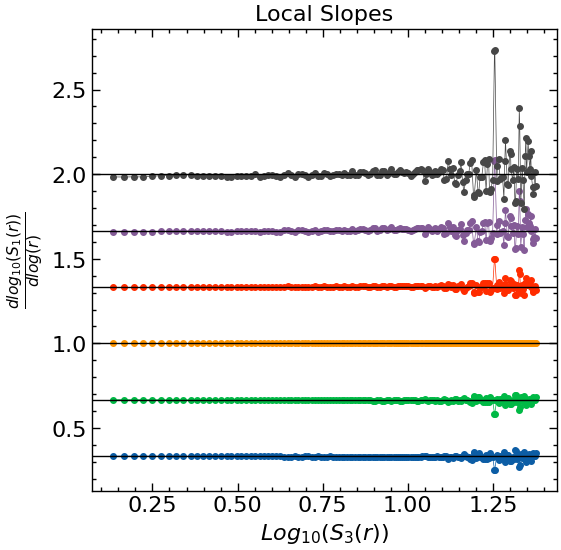

In [9]:
fig, ax1 = plt.subplots( figsize = (6,6))

for i in range(6):
    
    ax1.plot(logr[10:-30] , local_slopes[i,10:-30],'o-',lw = 0.5 , ms = 4)
    ax1.axhline((i+1)/3, c = 'black', lw = 1)
# ax1.axhline(1/3)

ax1.set_ylabel(r'$\frac{dlog_{10}(S_1(r))}{d log(r)}$')
ax1.set_xlabel(r"$Log_{10}(S_3(r))$")
ax1.set_title("Local Slopes")


# ax1.axvline((logr[15]))
# ax1.axvline((logr[65]))
# ax1.axvspan(np.log10(radial_dist[40]),np.log10(radial_dist[140]), alpha = 0.3)

plt.show() 

In [10]:
np.savez_compressed("Scaling_exponen_Homogeneous_P0p5", p = p , Xi_p = Xi_p , error = error)

# np.savez_compressed("local_slope_Fractal_D2p98", local_slope = local_slopes)

In [8]:
p = np.arange(0,7)


Xi_p_P0p0 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Homogeneous_P0p0.npz')['Xi_p']
error_P0p0 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Homogeneous_P0p0.npz')['error']

Xi_p_P0p05 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Homogeneous_P0p05.npz')['Xi_p']
error_P0p05 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Homogeneous_P0p05.npz')['error']


Xi_p_P0p1 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Homogeneous_P0p1.npz')['Xi_p']
error_P0p1 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Homogeneous_P0p1.npz')['error']


Xi_p_P0p3 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Homogeneous_P0p3.npz')['Xi_p']
error_P0p3 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Homogeneous_P0p3.npz')['error']


Xi_p_P0p5 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Homogeneous_P0p5.npz')['Xi_p']
error_P0p5 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Homogeneous_P0p5.npz')['error']

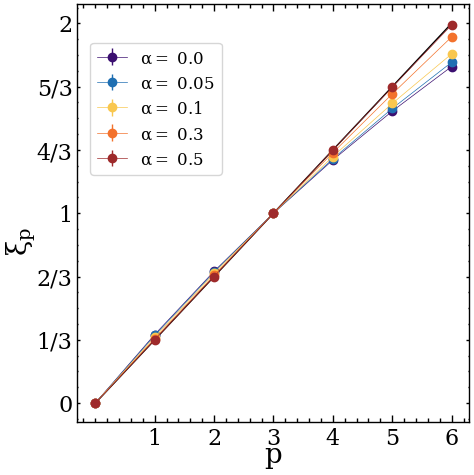

In [10]:
X = [0,3,5,7,10,30,50]
# bins_ref = np.append(np.array([0,1e-3,1e-2,1e-1]),np.arange(1,200,2))

# ---------- Style setup ----------
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.linewidth': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'ytick.major.size': 2,
    'xtick.minor.size': 3,
    'ytick.minor.size': 1,
    'legend.frameon': False,
    'mathtext.default': 'regular',
})

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(5,5), dpi=100)

ax.set_xlabel(r'$p$', labelpad=-15, size = 20)
ax.xaxis.set_label_coords(0.5, -0.05) # x=0.5 (center), y=-0.1 (below axis)

ax.set_ylabel(r'$\xi_p$', size = 20)
ax.yaxis.set_label_coords(-0.1, 0.435) # x=0.5 (center), y=-0.1 (below axis)

# ---------- Data ----------
labels = [0, 3, 5, 7, 10, 30, 50]
colors = [
    "#3b0f70",  # deep purple
    "#1f6fb2",  # deep blue
    "#2d6a4f",  # deep teal
    "#f9c74f",  # warm yellow (kept minimal)
    "#f3722c",  # deep orange
    "#9e2a2b",  # deep red
]
markers = ['o', 's', 'D', '*', '^', '.', '<']

alphas = [0.00, 0.03, 0.05, 0.07, 0.10, 0.30, 0.50]

markers = ['o','>' ,'s', 'D', 'p', 'h', '*']

# ---------- Plot curves ----------


plt.errorbar(p , Xi_p_P0p0, yerr = error_P0p0, ms = 6,marker = 'o',c = colors[0], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$\alpha =$ {alphas[0]}')
plt.errorbar(p , Xi_p_P0p05, yerr = error_P0p05, ms = 6,marker = 'o',c = colors[1], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$\alpha =$ {alphas[2]}')
plt.errorbar(p , Xi_p_P0p1, yerr = error_P0p1, ms = 6,marker = 'o',c = colors[3], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$\alpha =$ {alphas[4]}')
plt.errorbar(p , Xi_p_P0p3, yerr = error_P0p3, ms = 6,marker = 'o',c = colors[4], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$\alpha =$ {alphas[5]}')
plt.errorbar(p , Xi_p_P0p5, yerr = error_P0p5, ms = 6,marker = 'o',c = colors[5], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$\alpha =$ {alphas[6]}')

plt.plot(np.arange(0,7),np.arange(0,7)/3, color = 'black', lw = 1)



# ax.grid(True, which='major', linestyle='--', linewidth=0.4, alpha=0.5)


ax.legend(
    loc='center',
    bbox_to_anchor=(0.2, 0.75),  # (x, y) in axes fraction coordinates
    handlelength=1.8,
    frameon=True,
    prop={'size': 12}
)
# ax.set_yscale('log')
# ax.set_xscale('log')
ax.set_xticks([1, 2,3,4,5,6])
ax.set_xticklabels([1, 2,3,4,5,6])


ax.set_yticks(np.arange(0,2.01,1/3))
ax.set_yticklabels([0,'1/3','2/3',1,'4/3','5/3',2])

# ---------- Save ----------
plt.tight_layout()
plt.savefig('Structure_function.png', dpi = 300,bbox_inches='tight')
plt.show()

In [9]:
p = np.arange(0,7)


Xi_p_D_3p00 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Homogeneous_P0p0.npz')['Xi_p']
error_D_3p00 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Homogeneous_P0p0.npz')['error']

Xi_p_D_2p98 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Fractal_D2p98.npz')['Xi_p']
error_D_2p98 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Fractal_D2p98.npz')['error']


Xi_p_D_2p95 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Fractal_D2p95.npz')['Xi_p']
error_D_2p95 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Fractal_D2p95.npz')['error']

Xi_p_D_2p90 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Fractal_D2p90.npz')['Xi_p']
error_D_2p90 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Fractal_D2p90.npz')['error']

Xi_p_D_2p80 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Fractal_D2p80.npz')['Xi_p']
error_D_2p80 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/Scaling_exponen_Fractal_D2p80.npz')['error']

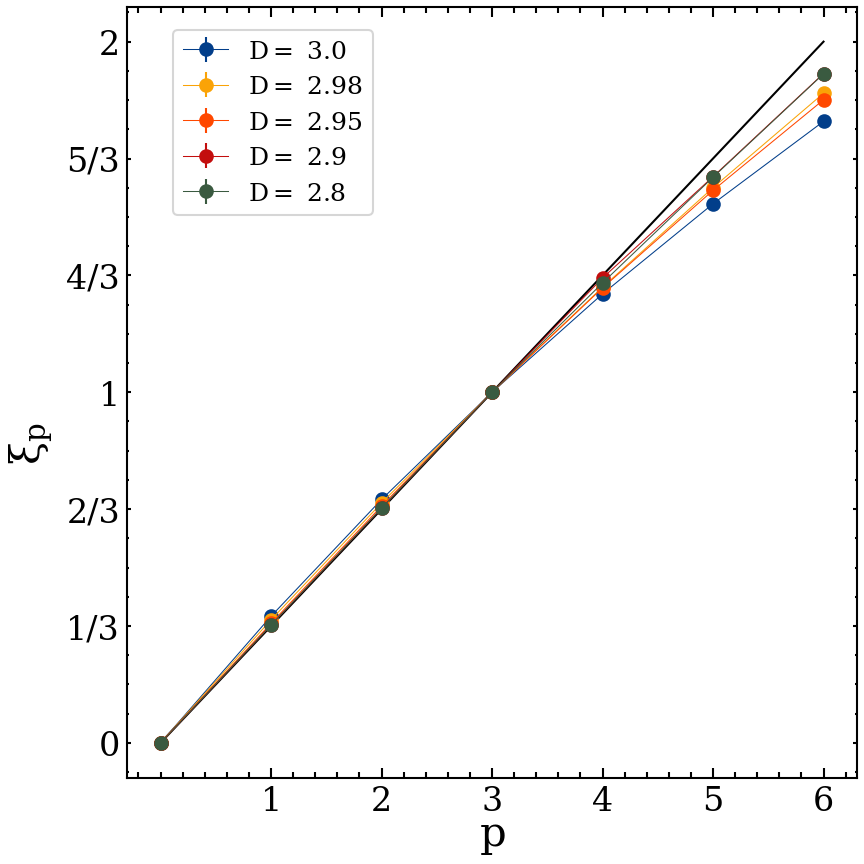

In [14]:
X = [0,3,5,7,10,30,50]
# bins_ref = np.append(np.array([0,1e-3,1e-2,1e-1]),np.arange(1,200,2))

# ---------- Style setup ----------
# plt.rcParams.update({
#     'font.family': 'serif',
#     'font.size': 12,
#     'axes.labelsize': 13,
#     'axes.titlesize': 14,
#     'axes.linewidth': 1.0,
#     'xtick.direction': 'in',
#     'ytick.direction': 'in',
#     'xtick.major.size': 5,
#     'ytick.major.size': 2,
#     'xtick.minor.size': 3,
#     'ytick.minor.size': 1,
#     'legend.frameon': False,
#     'mathtext.default': 'regular',
# })

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=(6,6), dpi=150)

ax.set_xlabel(r'$p$', labelpad=-15, size = 20)
ax.xaxis.set_label_coords(0.5, -0.05) # x=0.5 (center), y=-0.1 (below axis)

ax.set_ylabel(r'$\xi_p$', size = 20)
ax.yaxis.set_label_coords(-0.1, 0.435) # x=0.5 (center), y=-0.1 (below axis)

# ---------- Data ----------
labels = [0, 3, 5, 7, 10, 30, 50]



markers = ['o', 's', 'D', '*', '^', '.', '<']

# alphas = [0.00, 0.03, 0.05, 0.07, 0.10, 0.30, 0.50]

Dim  =  [3.00 , 2.98 , 2.95 , 2.90 , 2.80]

markers = ['o','>' ,'s', 'D', 'p', 'h', '*']

# ---------- Plot curves ----------


plt.errorbar(p , Xi_p_D_3p00, yerr = error_D_3p00, ms = 6,marker = 'o',c = colors[0], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$D =$ {Dim[0]}')
plt.errorbar(p , Xi_p_D_2p98, yerr = error_D_2p98, ms = 6,marker = 'o',c = colors[2], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$D =$ {Dim[1]}')
plt.errorbar(p , Xi_p_D_2p95, yerr = error_D_2p95, ms = 6,marker = 'o',c = colors[3], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$D =$ {Dim[2]}')
plt.errorbar(p , Xi_p_D_2p90, yerr = error_D_2p90, ms = 6,marker = 'o',c = colors[4], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$D =$ {Dim[3]}')
plt.errorbar(p , Xi_p_D_2p80, yerr = error_D_2p80, ms = 6,marker = 'o',c = colors[5], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$D =$ {Dim[4]}')

plt.plot(np.arange(0,7),np.arange(0,7)/3, color = 'black', lw = 1)



# ax.grid(True, which='major', linestyle='--', linewidth=0.4, alpha=0.5)


ax.legend(
    loc='center',
    bbox_to_anchor=(0.2, 0.85),  # (x, y) in axes fraction coordinates
    handlelength=1.8,
    frameon=True,
    prop={'size': 12}
)

ax.set_xticks([1, 2,3,4,5,6])
ax.set_xticklabels([1, 2,3,4,5,6])


ax.set_yticks(np.arange(0,2.01,1/3))
ax.set_yticklabels([0,'1/3','2/3',1,'4/3','5/3',2])

# ---------- Save ----------
plt.tight_layout()
plt.savefig('Structure_function.png', dpi = 300,bbox_inches='tight')
plt.show()

# Plotting Final

In [10]:
std_P0p0 = np.std(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p0.npz')['data'])
std_P0p1 = np.std(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p1.npz')['data'])
std_P0p3 = np.std(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p3.npz')['data'])
std_P0p5 = np.std(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p5.npz')['data'])

In [11]:
fourth_mom_P0p0 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p0.npz')['data']**6)
fourth_mom_P0p1 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p1.npz')['data']**6)
fourth_mom_P0p3 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p3.npz')['data']**6)
fourth_mom_P0p5 = np.mean(np.load('Struct_Func_data/Inertial_vel_increaments_r40_P0p5.npz')['data']**6)

In [12]:
kurtosis = jnp.array([fourth_mom_P0p0/std_P0p0**6 ,fourth_mom_P0p1/std_P0p1**6 , fourth_mom_P0p3/std_P0p3**6,fourth_mom_P0p5/std_P0p5**6])

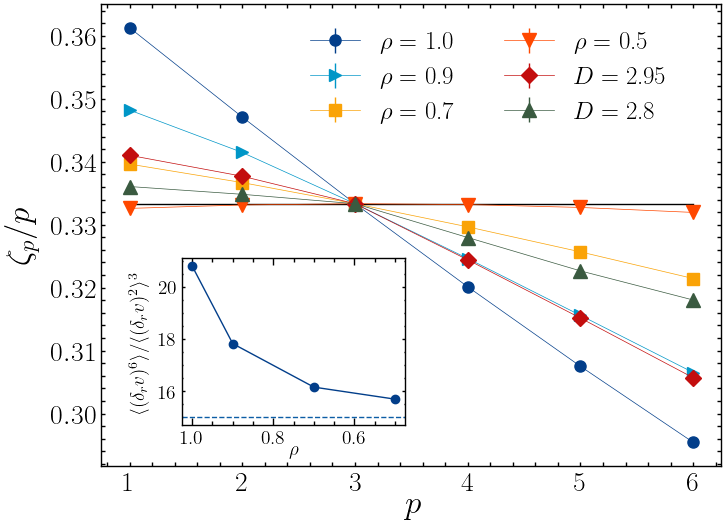

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -----------------------------
# FIGURE SETUP
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi = 100)

# Enable external LaTeX rendering
plt.rcParams['text.usetex'] = True


plt.rcParams.update({
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'axes.linewidth': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'ytick.major.size': 2,
    'xtick.minor.size': 3,
    'ytick.minor.size': 1,
    'legend.frameon': False,
})

ax.tick_params(
    axis='both',
    which='both',
    labelsize=22,   
    length=3,
    width=1,
    top=True,
    right=True
)


# ---------- Data ----------
labels = [0, 3, 5, 7, 10, 30, 50]
colors = [
    "#03045e",  # deep purple
    "#1f6fb2",  # deep blue
    "#2d6a4f",  # deep teal
    "#faa307",  # warm yellow (kept minimal)
    "#ff4800",  # deep orange
    "#9e2a2b",  # deep red
]
colors = ["#023e8a","#0096c7","#faa307","#ff4800","#c30e0e","#3a5a40"]
markers = ["o", ">","s","v", "D","^"]
alphas = [1.0, 0.97, 0.95, 0.93, 0.90, 0.70, 0.50]



# ---------- Plot curves ----------


plt.errorbar(p[1:] , Xi_p_P0p0[1:]/p[1:], yerr = error_P0p0[1:]/p[1:], ms = 8,marker = markers[0],c = colors[0], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$\rho =$ {alphas[0]}')
# plt.errorbar(p , Xi_p_P0p05, yerr = error_P0p05, ms = 6,marker = 's',c = colors[1], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$\rho =$ {alphas[2]}')
plt.errorbar(p[1:] , Xi_p_P0p1[1:]/p[1:], yerr = error_P0p1[1:]/p[1:], ms = 9,marker = markers[1],c = colors[1], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$\rho =$ {alphas[4]}')
plt.errorbar(p[1:] , Xi_p_P0p3[1:]/p[1:], yerr = error_P0p3[1:]/p[1:], ms = 8,marker = markers[2],c = colors[2], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$\rho =$ {alphas[5]}')
plt.errorbar(p[1:] , Xi_p_P0p5[1:]/p[1:], yerr = error_P0p5[1:]/p[1:], ms = 10,marker = markers[3],c = colors[3], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$\rho =$ {alphas[6]}')

plt.plot(np.arange(1,7),np.ones(6)/3, color = 'black', lw = 1)


# ax.set_yticks(np.arange(0,2.01,1/3))
# ax.set_yticklabels([0,'1/3','2/3',1,'4/3','5/3',2])



# ax.errorbar(p , Xi_p_D_3p00, yerr = error_D_3p00, ms = 6,marker = 'o',c = colors[0], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$D =$ {Dim[0]}')
# ax.errorbar(p , Xi_p_D_2p98, yerr = error_D_2p98, ms = 6,marker = 's',c = colors[1], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$D =$ {Dim[1]}')
ax.errorbar(p[1:] , Xi_p_D_2p95[1:]/p[1:], yerr = error_D_2p95[1:]/p[1:], ms = 8,marker = markers[4],c = colors[4], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$D=$ {Dim[2]}')
# ax.errorbar(p[1:] , Xi_p_D_2p90[1:]/p[1:], yerr = error_D_2p90[1:], ms = 6,marker = 'D',c = colors[4], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$D =$ {Dim[3]}')
ax.errorbar(p[1:] , Xi_p_D_2p80[1:]/p[1:], yerr = error_D_2p80[1:]/p[1:], ms = 10,marker = markers[5],c = colors[5], lw = 0.5,elinewidth = 1,capsize = 0, label = rf'$D =$ {Dim[4]}')


# -----------------------------
# MAIN AXES FORMATTING
# -----------------------------
ax.legend(loc='upper right', ncols = 2, bbox_to_anchor=(0.95, 0.99), fontsize = 18)

ax.set_xlabel(r'$p$', labelpad=-15, size = 24)
ax.xaxis.set_label_coords(0.5, -0.05) # x=0.5 (center), y=-0.1 (below axis)

ax.set_ylabel(r'$\zeta_p/p$', size = 24)
ax.yaxis.set_label_coords(-0.1, 0.5) # x=0.5 (center), y=-0.1 (below axis)




#------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------#



axins = inset_axes(
    ax,
    width="180%",
    height="180%",
    loc="upper right",
    bbox_to_anchor=(0.29, 0.25, 0.2, 0.2),   # full axes bbox
    bbox_transform=ax.transAxes,
    borderpad=0.0
)

alpha_kurt = np.array([1.0 , 0.9 , 0.7 , 0.5]) 

axins.plot(alpha_kurt, kurtosis, 'o-',lw=1, ms = 6 , c = colors[0])

axins.invert_xaxis()
axins.tick_params(labelsize=10)
axins.grid(False)

ax.tick_params(
    axis='both',
    which='both',
    labelsize=20   
)

axins.tick_params(
    axis='both',
    which='both',
    labelsize=14   
)


axins.set_xlabel(r'$ \rho$', labelpad=-15, size = 14)
axins.xaxis.set_label_coords(0.5, -0.1) 

axins.set_ylabel(r'$\langle (\delta_r v)^6 \rangle$/$\langle (\delta_r v)^2 \rangle^3$', size = 14)
axins.yaxis.set_label_coords(-0.15, 0.5) 

# axins.set_xticks(np.array([1 ,  0.75 ,0.5]))
# axins.set_xticklabels(np.array([1 ,  0.75 ,0.5]))


# axins.set_yticks(np.array([3 ,  3.2 ,3.4]))
# axins.set_yticklabels(np.array([3 ,  3.2 ,3.4]))

axins.axhline(15, ls = '--', lw = 1)
plt.savefig("Structure_function_decimated_NS.png", dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

In [17]:
local_0p0 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/local_slope_Homogeneous_P0p0.npz')['local_slope']
local_0p05 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/local_slope_Homogeneous_P0p05.npz')['local_slope']
local_0p1 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/local_slope_Homogeneous_P0p1.npz')['local_slope']
local_0p3 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/local_slope_Homogeneous_P0p3.npz')['local_slope']
local_0p5 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/local_slope_Homogeneous_P0p5.npz')['local_slope']

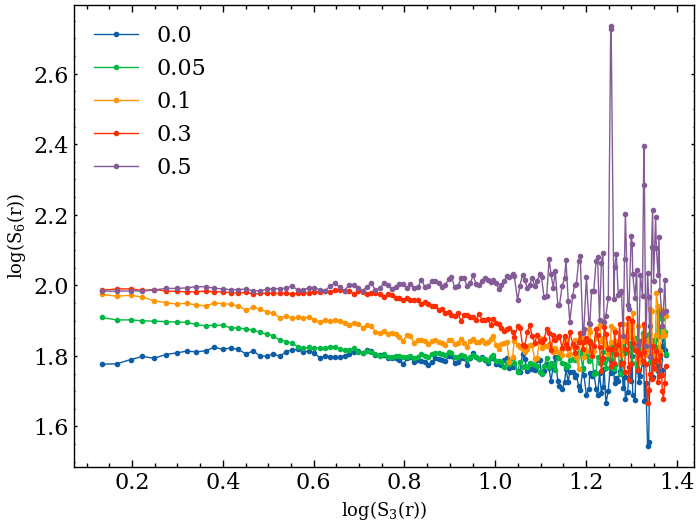

In [18]:
alphas_new = [0.00,  0.05, 0.10, 0.30, 0.50]


plt.plot(logr[10:-30], local_0p0[5,10:-30], 'o-' , ms = 3 , lw = 1, label = alphas_new[0] )
plt.plot(logr[10:-30], local_0p05[5,10:-30], 'o-' , ms = 3 , lw = 1, label = alphas_new[1])
plt.plot(logr[10:-30], local_0p1[5,10:-30], 'o-' , ms = 3 , lw = 1, label = alphas_new[2])
plt.plot(logr[10:-30], local_0p3[5,10:-30], 'o-' , ms = 3 , lw = 1, label = alphas_new[3])
plt.plot(logr[10:-30], local_0p5[5,10:-30], 'o-' , ms = 3 , lw = 1, label = alphas_new[4])

plt.xlabel(r'log($S_3(r)$)')
plt.ylabel(r'log($S_6(r)$)')
plt.legend()

In [19]:
local_0p0 = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/local_slope_Homogeneous_P0p0.npz')['local_slope']
local_D2p98  = np.load("/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/local_slope_Fractal_D2p98.npz")['local_slope']
local_D2p95 =  np.load("/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/local_slope_Fractal_D2p95.npz")['local_slope']
local_D2p90 =  np.load("/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/local_slope_Fractal_D2p90.npz")['local_slope']
local_D2p80 = np.load("/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Struct_Func_data/local_slope_Fractal_D2p80.npz")['local_slope']

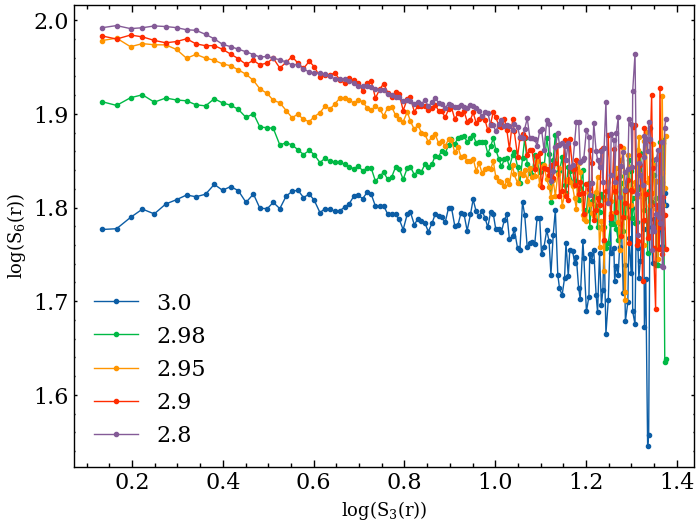

In [20]:
Dim  =  [3.00 , 2.98 , 2.95 , 2.90 , 2.80]

plt.plot(logr[10:-30], local_0p0[5,10:-30], 'o-' , ms = 3 , lw = 1, label = Dim[0] )
plt.plot(logr[10:-30], local_D2p98[5,10:-30], 'o-' , ms = 3 , lw = 1, label = Dim[1])
plt.plot(logr[10:-30], local_D2p95[5,10:-30], 'o-' , ms = 3 , lw = 1, label = Dim[2])
plt.plot(logr[10:-30], local_D2p90[5,10:-30], 'o-' , ms = 3 , lw = 1, label = Dim[3])
plt.plot(logr[10:-30], local_D2p80[5,10:-30], 'o-' , ms = 3 , lw = 1, label = Dim[4])

plt.xlabel(r'log($S_3(r)$)')
plt.ylabel(r'log($S_6(r)$)')
plt.legend()